In [44]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [24]:
df = pd.read_csv("bmw.csv")

In [25]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [26]:
df['fuelType'].value_counts()

,count
fuelType,
Diesel,7027
Petrol,3417
Hybrid,298
Other,36
Electric,3


In [27]:
df.shape

(10781, 9)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  object 
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  object 
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  object 
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 758.2+ KB


In [29]:
df.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


In [30]:
df = df.drop_duplicates(keep='first')

In [31]:
df.shape

(10664, 9)

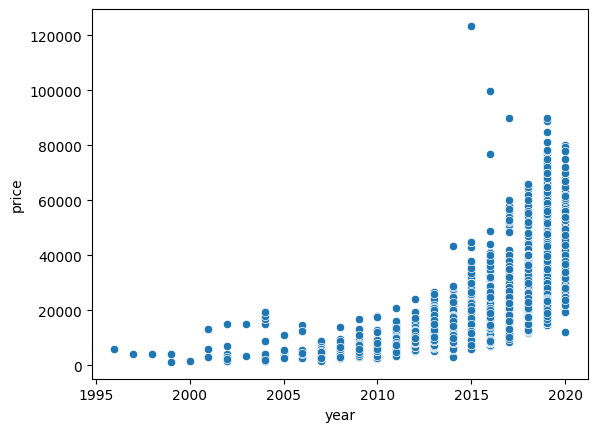

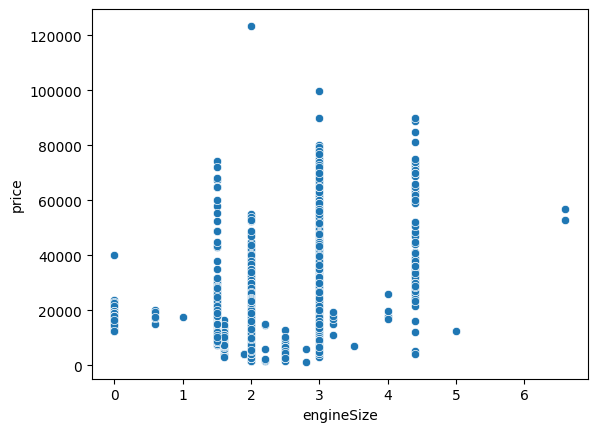

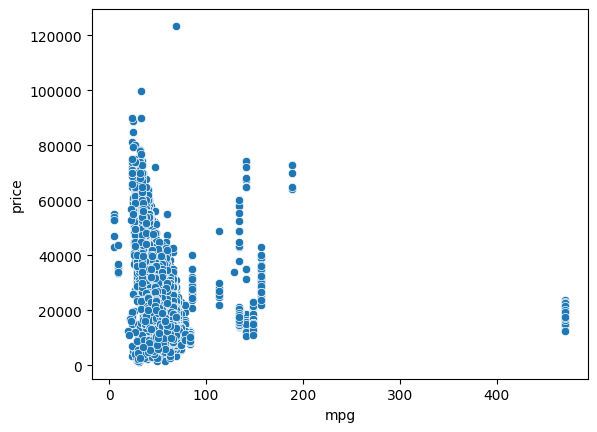

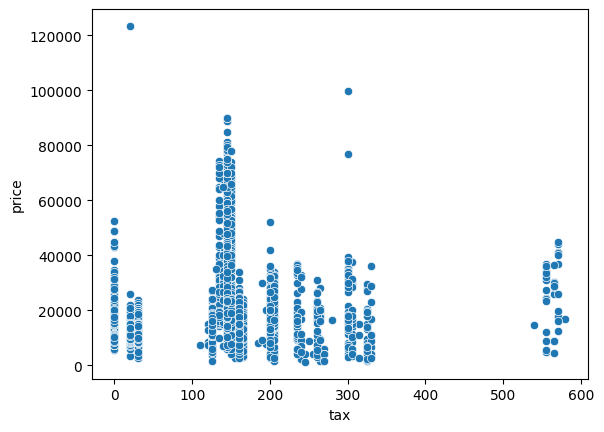

In [32]:
cols = ['year','engineSize','mpg','tax']
for col in cols:
  sns.scatterplot(data=df,x=col,y=df['price'])
  plt.show()

<Axes: xlabel='price', ylabel='engineSize'>

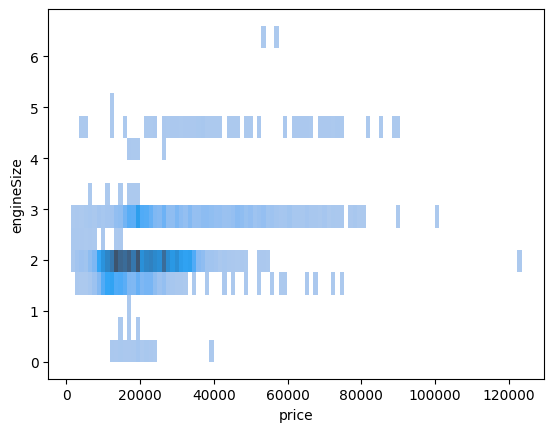

In [33]:
sns.histplot(data = df,x = 'price',y = 'engineSize',kde=True)

In [34]:
X = df.drop('price',axis=1)
y = df['price']

In [35]:
num_x = X.select_dtypes(include=['int64','float64'])
cat_x = X.select_dtypes(include='object')

In [36]:
num_x_enc = Pipeline([
    ('scalar',StandardScaler())
])
cat_x_enc = Pipeline([
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

In [37]:
preprocessor = ColumnTransformer([
    ('num',num_x_enc,num_x.columns),
    ('cat',cat_x_enc,cat_x.columns)
])

In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=df['fuelType'])

In [39]:
lr = LinearRegression()

In [40]:
model = Pipeline([
    ('preprocessor',preprocessor),
    ('lr',lr)
])

In [41]:
model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scalar',
                                                                   StandardScaler())]),
                                                  Index(['year', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['model', 'transmission', 'fuelType'], dtype='object'))])),
                ('lr', LinearRegression())])

In [42]:
y_pred = model.predict(X_test)

In [43]:
y_pred


array([21798.59666272, 17525.0633515 , 20786.37076732, ...,
       27320.96212088, 23973.16347629, 37029.53117219])

In [46]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
rmse = np.sqrt(mse)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2: {r2}")
print(f"RMSE: {rmse}")

MSE: 22311331.669423092
MAE: 2861.8655688952667
R2: 0.8414524382146552
RMSE: 4723.487236081314


In [49]:
from sklearn.model_selection import KFold,cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring='r2'
)

print("Fold R² scores:", scores)
print("Mean R²:", scores.mean())

Fold R² scores: [0.85601673 0.87637334 0.88618086 0.83778383 0.87358183]
Mean R²: 0.8659873180384231
